# Event-level observables

Moves from per-PFO classification to per-event quantities: multiplicity, mean
and max classifier score, number of tagged signal PFOs, mean track score.

The question is whether simple aggregates carry topology information. If mean
score per event separates 0-signal from 1-signal from multi-signal events, an
event-level classifier could use it. If it does not, the FSI topology model
needs the per-PFO scores themselves rather than summaries of them.

## Setup

In [1]:
import pickle

import numpy as np
import matplotlib.pyplot as plt

from utils.general_utils import (PROJECT_ROOT, SPECIES_COLORS,
                                 species_label, target_config)

TARGET = "photon"          # "pion" | "photon"
cfg    = target_config(TARGET)

# Symbols used throughout the labels. Everything below follows TARGET, so a
# photon run does not claim to be counting pions.
SYM   = {"pion": r"$\pi^{\pm}$", "photon": r"$\gamma$"}[TARGET]
SHORT = {"pion": "π", "photon": "γ"}[TARGET]

TRACKS_PATH = PROJECT_ROOT / "prepared" / "prepared-mc" / "test_tracks.pkl"
with open(TRACKS_PATH, "rb") as f:
    tracks = pickle.load(f)
species = np.array([species_label(t) for t in tracks])

PRED_DIR = PROJECT_ROOT / "predictions" / "predictions-mc"
PRED_PATHS = {
    "mlp":    PRED_DIR / f"mlp_summary{cfg['suffix']}.pkl",
    "cnn":    PRED_DIR / f"cnn_dEdX{cfg['suffix']}.pkl",
    "hybrid": PRED_DIR / f"hybrid_cnn_mlp{cfg['suffix']}.pkl",
}

PLOTS_DIR = PROJECT_ROOT / "plots" / "event-analysis" / TARGET
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


def topo_bin(n):
    """Signal-count topology proxy: 0, 1, >=2."""
    return 0 if n == 0 else (1 if n == 1 else 2)


TOPO_COLORS        = ["#6b7280", "#4a90d9", "#d1495b"]
TOPO_LABELS_LEGEND = [f"true 0 {SYM}", f"true 1 {SYM}", f"true ≥2 {SYM}"]
TOPO_LABELS_AXIS   = [f"0 {SHORT}", f"1 {SHORT}", f"≥2 {SHORT}"]

print(f"target: {TARGET}  ({cfg['signal_name']})")
print(f"{len(tracks):,} test PFOs")

target: photon  ($\gamma$ (beam $\pi^0$))
126,817 test PFOs


## Build rows (pick which model to analyse via MODEL_KEY)
One row per event: multiplicity, score aggregates, tagged and true signal
counts, and mean track score

In [2]:
MODEL_KEY = "hybrid"                # "mlp" | "cnn" | "hybrid"
MODEL     = MODEL_KEY.capitalize()  # used in titles and filenames

with open(PRED_PATHS[MODEL_KEY], "rb") as f:
    d = pickle.load(f)

probs  = np.asarray(d["probs"])
labels = np.asarray(d["labels"]).astype(int)   # 1 = true signal
thr    = d["threshold"]
preds  = (probs >= thr).astype(int)            # 1 = tagged signal

assert len(tracks) == len(probs), \
    "tracks and predictions are not aligned — check ordering"

track_score = np.array([float(t["track_score"]) for t in tracks])
event_ids   = np.array([t["event_number"] for t in tracks])

# Compact event index, so every per-event array lines up without a lookup.
uniq, ev_idx = np.unique(event_ids, return_inverse=True)
n_ev = len(uniq)

mult    = np.bincount(ev_idx, minlength=n_ev)
n_tag   = np.bincount(ev_idx, weights=preds,  minlength=n_ev).astype(int)
n_tru   = np.bincount(ev_idx, weights=labels, minlength=n_ev).astype(int)
sum_sc  = np.bincount(ev_idx, weights=probs,  minlength=n_ev)
sum_ts  = np.bincount(ev_idx, weights=track_score, minlength=n_ev)
mean_sc = sum_sc / mult
mean_ts = sum_ts / mult

max_sc = np.zeros(n_ev)
np.maximum.at(max_sc, ev_idx, probs)

tb = np.array([topo_bin(n) for n in n_tru])    # true topology bin per event

print(f"{n_ev:,} events, {mult.mean():.1f} PFOs per event on average")
for k, lab in enumerate(TOPO_LABELS_AXIS):
    print(f"  {lab:<6} {int((tb == k).sum()):>7,} events")

38,082 events, 3.3 PFOs per event on average
  0 γ     27,379 events
  1 γ      5,056 events
  ≥2 γ     5,647 events


## Event-level observables

Stacked by **true** topology bin, so the question is whether the three colours
occupy different regions or are simply scaled copies of one another.

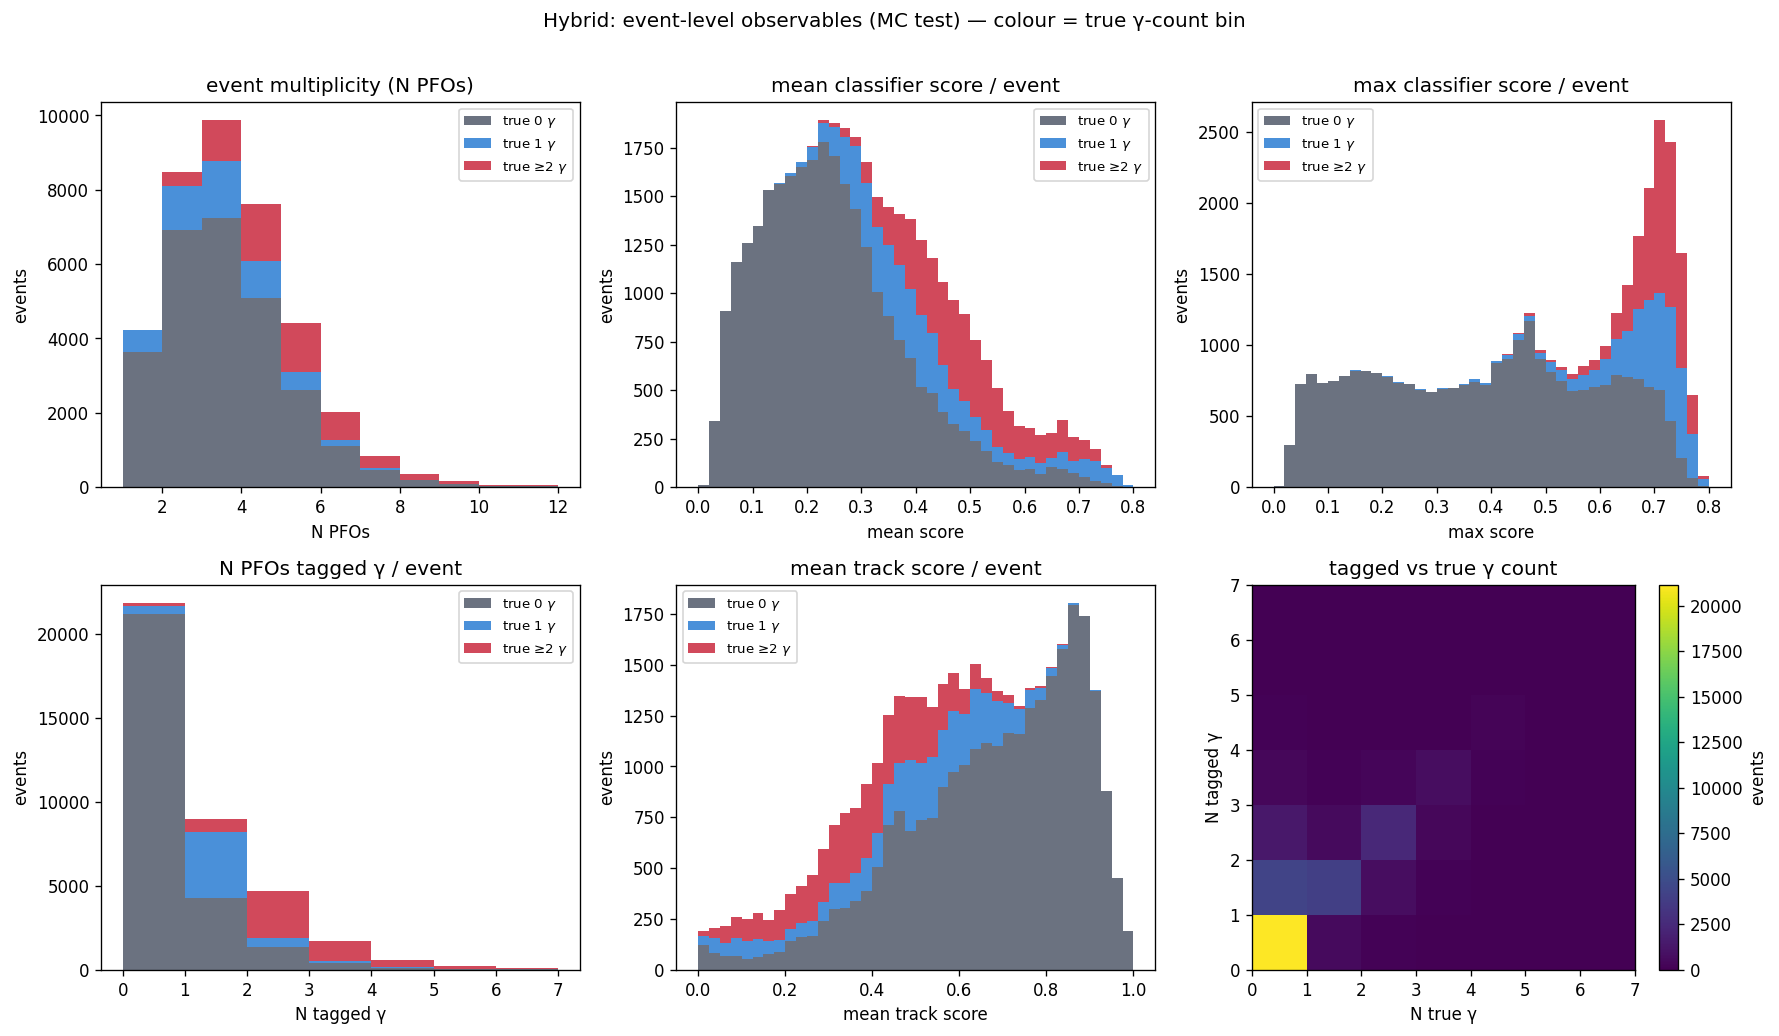

Saved /home/pemb7173/PDSP-pion-classification/plots/event-analysis/photon/event_observables_Hybrid_photon.pdf


In [3]:
def split(x):
    """Split an event-level array by true topology bin."""
    return [x[tb == k] for k in range(3)]


fig, ax = plt.subplots(2, 3, figsize=(15, 8.5), dpi=120)

ax[0, 0].hist(split(mult), bins=range(1, 13), stacked=True,
              color=TOPO_COLORS, label=TOPO_LABELS_LEGEND)
ax[0, 0].set_title("event multiplicity (N PFOs)")
ax[0, 0].set_xlabel("N PFOs")

ax[0, 1].hist(split(mean_sc), bins=np.linspace(0, 0.8, 41), stacked=True,
              color=TOPO_COLORS, label=TOPO_LABELS_LEGEND)
ax[0, 1].set_title("mean classifier score / event")
ax[0, 1].set_xlabel("mean score")

ax[0, 2].hist(split(max_sc), bins=np.linspace(0, 0.8, 41), stacked=True,
              color=TOPO_COLORS, label=TOPO_LABELS_LEGEND)
ax[0, 2].set_title("max classifier score / event")
ax[0, 2].set_xlabel("max score")

ax[1, 0].hist(split(n_tag), bins=range(0, 8), stacked=True,
              color=TOPO_COLORS, label=TOPO_LABELS_LEGEND)
ax[1, 0].set_title(f"N PFOs tagged {SHORT} / event")
ax[1, 0].set_xlabel(f"N tagged {SHORT}")

ax[1, 1].hist(split(mean_ts), bins=np.linspace(0, 1, 41), stacked=True,
              color=TOPO_COLORS, label=TOPO_LABELS_LEGEND)
ax[1, 1].set_title("mean track score / event")
ax[1, 1].set_xlabel("mean track score")

h = ax[1, 2].hist2d(n_tru, n_tag, bins=[range(0, 8), range(0, 8)], cmap="viridis")
fig.colorbar(h[3], ax=ax[1, 2], label="events")
ax[1, 2].set_xlabel(f"N true {SHORT}")
ax[1, 2].set_ylabel(f"N tagged {SHORT}")
ax[1, 2].set_title(f"tagged vs true {SHORT} count")

for a in ax.ravel()[:5]:
    a.set_ylabel("events")
    a.legend(fontsize=8)

plt.suptitle(f"{MODEL}: event-level observables (MC test) — "
             f"colour = true {SHORT}-count bin", y=1.01)
plt.tight_layout()

out_path = PLOTS_DIR / f"event_observables_{MODEL}_{TARGET}.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

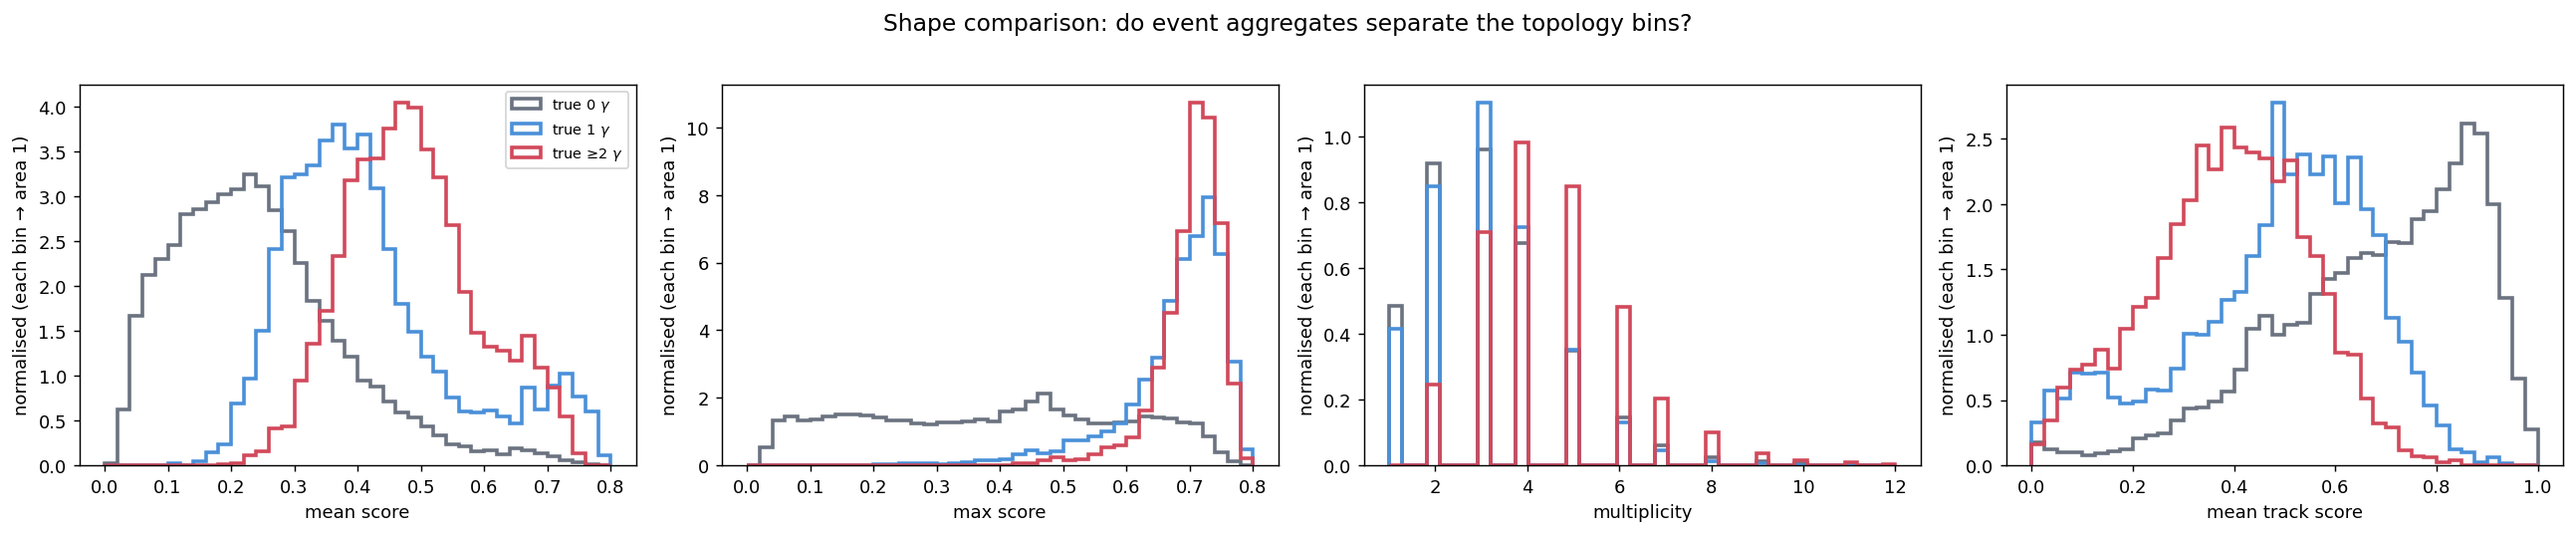

observable              0 vs 1   0 vs ≥2   1 vs ≥2
--------------------------------------------------
mean score                1.29      2.03      0.56
max score                 1.87      2.14      0.35
multiplicity              0.00      0.92      0.96
mean track score          1.00      1.62      0.55

(separation in pooled standard deviations; < 0.2 is negligible)


In [4]:
# The stacked plots make separation hard to judge by eye, because the three
# bins have very different populations. This normalises each bin to unit area
# and quantifies the separation.
from itertools import combinations

OBS = [("mean score", mean_sc, (0, 0.8)),
       ("max score",  max_sc,  (0, 0.8)),
       ("multiplicity", mult.astype(float), (1, 12)),
       ("mean track score", mean_ts, (0, 1))]

fig, ax = plt.subplots(1, len(OBS), figsize=(5*len(OBS), 4), dpi=130)
for j, (name, v, rng) in enumerate(OBS):
    b = np.linspace(*rng, 41)
    for k, (lab, col) in enumerate(zip(TOPO_LABELS_LEGEND, TOPO_COLORS)):
        ax[j].hist(v[tb == k], bins=b, histtype='step', density=True,
                   lw=2, color=col, label=lab)
    ax[j].set_xlabel(name)
    ax[j].set_ylabel("normalised (each bin → area 1)")
ax[0].legend(fontsize=8)
fig.suptitle("Shape comparison: do event aggregates separate the topology bins?",
             fontsize=13, y=1.02)
plt.tight_layout()
out_path = PLOTS_DIR / f"event_aggregate_shapes_{MODEL}_{TARGET}.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()

# Numerical separation: mean of each bin, in units of the pooled spread.
print(f"{'observable':<20}{'0 vs 1':>10}{'0 vs ≥2':>10}{'1 vs ≥2':>10}")
print("-" * 50)
for name, v, _ in OBS:
    seps = []
    for a, b_ in combinations(range(3), 2):
        va, vb = v[tb == a], v[tb == b_]
        pooled = np.sqrt(0.5 * (va.var() + vb.var()))
        seps.append(abs(va.mean() - vb.mean()) / pooled if pooled > 0 else 0.0)
    print(f"{name:<20}{seps[0]:>10.2f}{seps[1]:>10.2f}{seps[2]:>10.2f}")
print("\n(separation in pooled standard deviations; < 0.2 is negligible)")

## Topology-bin migration

How often the tagged signal count lands in the same bin as the true count.

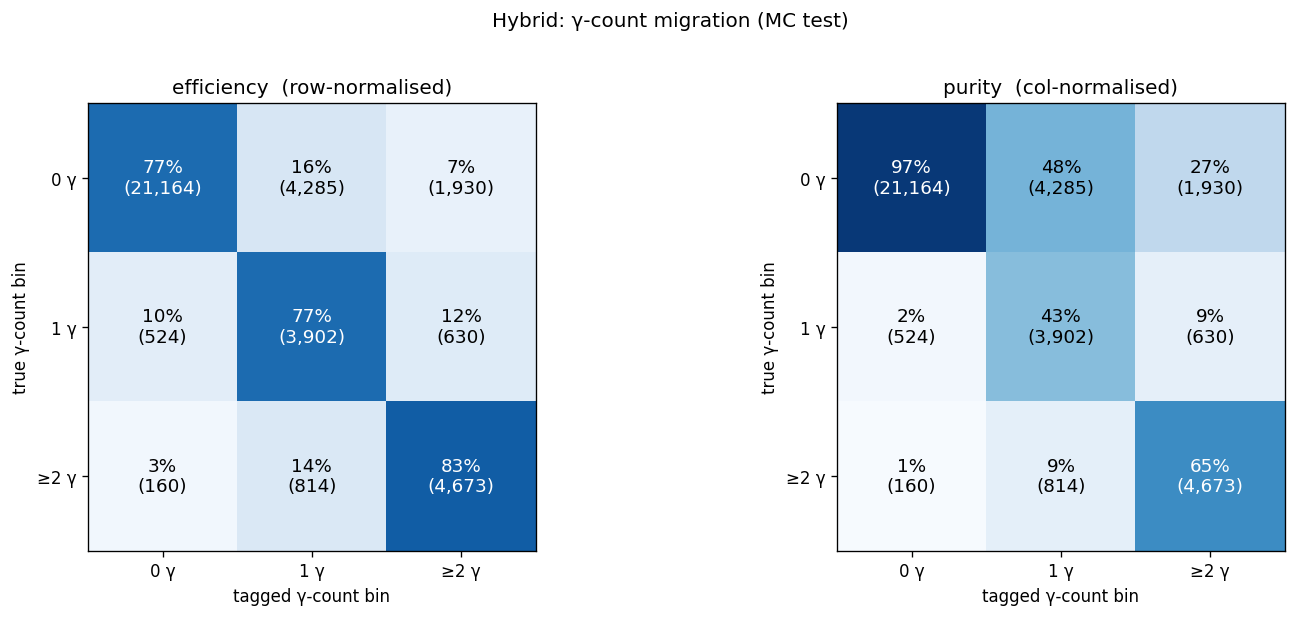

diagonal (correct bin): 78.1% of events


In [5]:
# topology migration matrices
true_b = tb
tag_b  = np.array([topo_bin(n) for n in n_tag])

M = np.zeros((3, 3), int)          # M[true, tagged]
for t, g in zip(true_b, tag_b):
    M[t, g] += 1

eff = M / M.sum(axis=1, keepdims=True).clip(min=1)   # row-normalised
pur = M / M.sum(axis=0, keepdims=True).clip(min=1)   # column-normalised

fig, ax = plt.subplots(1, 2, figsize=(13, 5), dpi=120)
for a, Mat, ttl in [(ax[0], eff, "efficiency  (row-normalised)"),
                    (ax[1], pur, "purity  (col-normalised)")]:
    a.imshow(Mat, cmap="Blues", vmin=0, vmax=1)
    a.set_xticks(range(3)); a.set_xticklabels(TOPO_LABELS_AXIS)
    a.set_yticks(range(3)); a.set_yticklabels(TOPO_LABELS_AXIS)
    a.set_xlabel(f"tagged {SHORT}-count bin")
    a.set_ylabel(f"true {SHORT}-count bin")
    a.set_title(ttl)
    for i in range(3):
        for j in range(3):
            a.text(j, i, f"{Mat[i, j]*100:.0f}%\n({M[i, j]:,})",
                   ha="center", va="center", fontsize=11,
                   color="white" if Mat[i, j] > 0.5 else "black")

plt.suptitle(f"{MODEL}: {SHORT}-count migration (MC test)", y=1.02)
plt.tight_layout()
out_path = PLOTS_DIR / f"topology_migration_{MODEL}_{TARGET}.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()

print(f"diagonal (correct bin): {np.trace(M)/M.sum()*100:.1f}% of events")